In [ ]:
!pip install lightkurve

In [ ]:
import lightkurve as lk
import matplotlib.pyplot as plt
search_result = lk.search_lightcurve('TIC 286923464', author='SPOC')
lc = search_result[0].download()
display(lc)

time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
1711.3621370287622,1.6672331e+05,4.5256226e+01,-2.8763246e-03,348415,1328.20934,1818.99084,1.5899677e+05,4.3074539e+01,2.4432942e+03,6.9369702e+00,1.6672331e+05,4.5256226e+01,0,———,———,———,———,1328.20934,2.4524870e-04,1818.99084,2.1416463e-04,1.0248361e-02,8.9072492e-03
1711.36352588119,1.6687795e+05,4.5283237e+01,-2.8763604e-03,348416,1328.20701,1818.98695,1.5920242e+05,4.3100246e+01,2.4472327e+03,6.9385748e+00,1.6687795e+05,4.5283237e+01,0,———,———,———,———,1328.20701,2.4491773e-04,1818.98695,2.1398996e-04,7.8623574e-03,4.8340480e-03
1711.364914733618,1.6681752e+05,4.5270245e+01,-2.8763963e-03,348417,1328.20872,1818.98552,1.5910572e+05,4.3087883e+01,2.4462356e+03,6.9370313e+00,1.6681752e+05,4.5270245e+01,0,———,———,———,———,1328.20872,2.4502081e-04,1818.98552,2.1406308e-04,8.6989934e-03,3.2905512e-03
1711.3663035862794,1.6678802e+05,4.5271255e+01,-2.8764319e-03,348418,1328.21456,1818.98771,1.5910534e+05,4.3088840e+01,2.4444651e+03,6.9450417e+00,1.6678802e+05,4.5271255e+01,0,———,———,———,———,1328.21456,2.4514052e-04,1818.98771,2.1403456e-04,1.5322545e-02,5.7209600e-03
1711.3676924387082,1.6682947e+05,4.5276684e+01,-2.8764678e-03,348419,1328.20657,1818.98474,1.5912961e+05,4.3094009e+01,2.4453652e+03,6.9421673e+00,1.6682947e+05,4.5276684e+01,0,———,———,———,———,1328.20657,2.4485597e-04,1818.98474,2.1412298e-04,7.3069348e-03,1.9326042e-03
1711.3690812911361,1.6683812e+05,4.5276932e+01,-2.8765036e-03,348420,1328.21494,1818.98888,1.5912647e+05,4.3094246e+01,2.4458669e+03,6.9576850e+00,1.6683812e+05,4.5276932e+01,0,———,———,———,———,1328.21494,2.4512986e-04,1818.98888,2.1422587e-04,1.5970275e-02,6.5271626e-03
1711.3704701437969,1.6684527e+05,4.5271408e+01,-2.8765392e-03,348421,1328.20668,1818.98870,1.5909786e+05,4.3088989e+01,2.4489561e+03,6.9463472e+00,1.6684527e+05,4.5271408e+01,0,———,———,———,———,1328.20668,2.4516453e-04,1818.98870,2.1395035e-04,7.6922989e-03,6.6291033e-03
1711.3718589962257,1.6683486e+05,4.5274319e+01,-2.8765751e-03,348422,1328.20669,1818.98668,1.5913038e+05,4.3091759e+01,2.4455186e+03,6.9375677e+00,1.6683486e+05,4.5274319e+01,0,———,———,———,———,1328.20669,2.4488199e-04,1818.98668,2.1406198e-04,6.8220124e-03,4.7585103e-03


<Axes: title={'center': 'Light Curve'}, xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

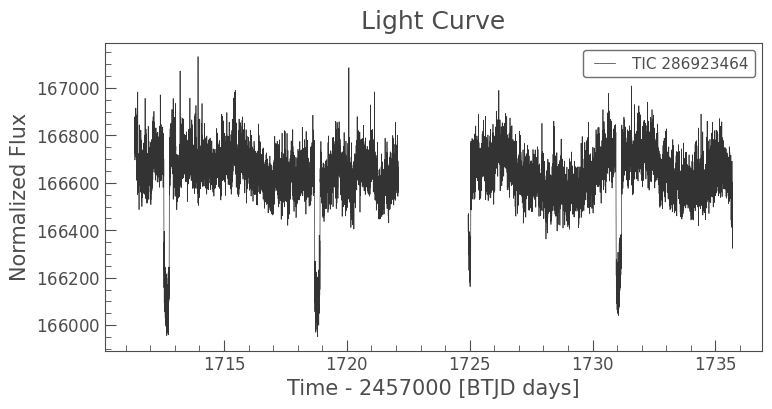

In [ ]:
lc.plot(title="Light Curve", ylabel="Normalized Flux")

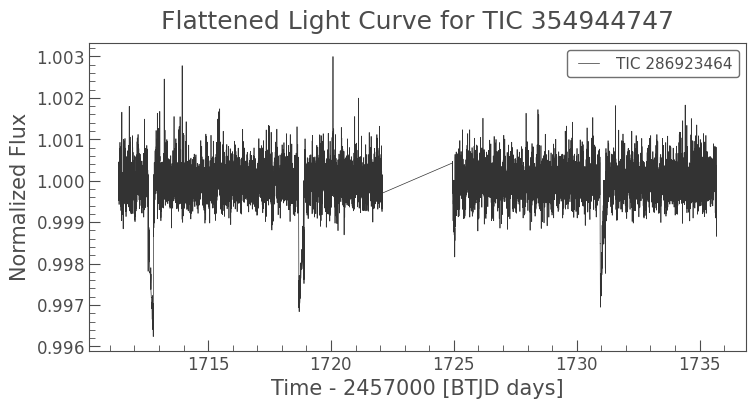

In [ ]:
wclean_lc = lc.remove_nans().remove_outliers()
flat_lc = clean_lc.flatten(window_length=401)
flat_lc.plot(title=f"Flattened Light Curve for TIC 354944747", ylabel="Normalized Flux")
plt.show()

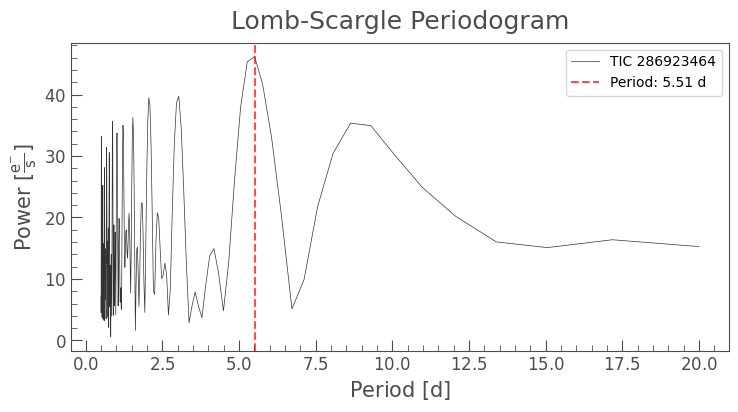

In [ ]:
  pg = lc.to_periodogram(method='lombscargle', minimum_period=0.5, maximum_period=20)
rotation_period = pg.period_at_max_power
pg.plot(view='period', title="Lomb-Scargle Periodogram")
plt.axvline(rotation_period.value, color='red', linestyle='--', alpha=0.7, label=f'Period: {rotation_period.value:.2f} d')
plt.legend()
plt.show()

In [ ]:
!pip install lightkurve astroquery gspread

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

import pandas as pd
from astroquery.mast import Catalogs
import lightkurve as lk
import os

In [ ]:
# Using the provided spreadsheet URL
spreadsheet_url = 'https://docs.google.com/spreadsheets/d/11qweSirx5cmyCW3T3pH_D_tPZpZ8WQRmyUbfR_p1mI4/edit'
worksheet = gc.open_by_url(spreadsheet_url).sheet1

# Get all values and convert to DataFrame
rows = worksheet.get_all_values()
df = pd.DataFrame.from_records(rows[1:], columns=rows[0])

display(df.head())

,Star Name,Accel Significance (sigma),Max Planet Sep,Max Brown Dwarf Sep,Astrometric Prediction,Kyle Notes,Bp-Rp Color,Effective Temperature,Chronologist,Good for Gyro Ages,...,TESS Sectors,Light Curve Plot,Variability?,Quality,Lomb-Scargle Plot,Rotation Period,Rotation Period Uncertainty,Gyro Age,Gyro Age Uncertainty,Notes
0,HIP 61901,147.644835,-99,1.187877733,,"Single system, no age data in Vizier",1.3711414,4544.63751,Ethan,,...,,,,,,,,,,
1,HIP 103393,8.240824082,1.049593231,2.626754104,,"UPDATE, wide companion is causing the accelera...",2.704154,3313.34057,Will,,...,,,,,,,,,,
2,HIP 63618,8.83088309,0.7598700463,1.970733782,,"Single star, no age data in Vizier, promising ...",1.5192704,4315.02144,Yasmin,,...,,,,,,,,,,
3,HIP 65143,13.90139014,1.156280131,2.814812361,,"Single star, age in Vizier of 5 Gyr from 2 cat...",2.090705,3659.295,Crimson,,...,,,,,,,,,,
4,HIP 35495,35.97002483,-99,1.288666217,,"Single star, no age data in Vizier, promising ...",1.8813772,3824.53711,Niteesh,,...,,,,,,,,,,


In [ ]:
import time

def get_tic_from_hip(hip_id):
    try:
        # Resolve HIP to TIC using MAST catalog
        clean_id = str(hip_id).upper().replace('HIP', '').strip()
        result = Catalogs.query_object(f"HIP {clean_id}", radius=0.001, catalog="TIC")
        if len(result) > 0:
            return f"TIC {result[0]['ID']}"
    except Exception as e:
        print(f"Error resolving HIP {hip_id}: {e}")
    return None

# Create directory to save light curves
os.makedirs('light_curves', exist_ok=True)

lc_collection = []

# Loop through stars and download light curves
for star_name in df['Star Name']:
    tic_id = get_tic_from_hip(star_name)
    if tic_id:
        try:
            print(f"Searching for {tic_id} ({star_name})...")
            search = lk.search_lightcurve(tic_id, author='SPOC')
            if len(search) > 0:
                # Download the first available light curve
                lc = search[0].download()
                if lc:
                    filename = f"light_curves/{tic_id.replace(' ', '_')}.fits"
                    lc.to_fits(filename, overwrite=True)
                    lc_collection.append(lc)
                    print(f"Saved {filename}")
            else:
                print(f"No SPOC light curve found for {star_name}")
        except Exception as e:
            print(f"Could not download {star_name}: {e}")

    # Add 2 second gap between each search
    time.sleep(2)

print(f"\nFinished. Downloaded {len(lc_collection)} light curves.")

Searching for TIC 460814512 (HIP 61901)...
Saved light_curves/TIC_460814512.fits
Searching for TIC 248807074 (HIP 103393)...
Saved light_curves/TIC_248807074.fits
Searching for TIC 229047482 (HIP 63618)...
Saved light_curves/TIC_229047482.fits
Searching for TIC 43133318 (HIP 65143)...
Saved light_curves/TIC_43133318.fits
Searching for TIC 302820286 (HIP 35495)...
Saved light_curves/TIC_302820286.fits


Searching for TIC 185284200 (HIP 71957)...
Saved light_curves/TIC_185284200.fits
Searching for TIC 233635503 (HIP 47741)...
Saved light_curves/TIC_233635503.fits
Searching for TIC 147670988 (HIP 60398)...
Saved light_curves/TIC_147670988.fits
Searching for TIC 251281112 (HIP 13714)...
Saved light_curves/TIC_251281112.fits
Searching for TIC 1825871 (HIP 84277)...
No SPOC light curve found for HIP 84277
Searching for TIC 418189606 (HIP 98677)...
Saved light_curves/TIC_418189606.fits
Searching for TIC 283410775 (HIP 108706)...
Saved light_curves/TIC_283410775.fits
Searching for TIC 75231315 (HIP 99385)...
Saved light_curves/TIC_75231315.fits
Searching for TIC 52217325 (HIP 57361)...
Saved light_curves/TIC_52217325.fits
Searching for TIC 450102450 (HIP 22627)...
Saved light_curves/TIC_450102450.fits
Searching for TIC 65673065 (HIP 36985)...
Saved light_curves/TIC_65673065.fits
Searching for TIC 274764311 (HIP 98921)...
Saved light_curves/TIC_274764311.fits
Searching for TIC 466335247 (HIP 

Saved light_curves/TIC_268804174.fits
Searching for TIC 206238826 (HIP 108036)...
Saved light_curves/TIC_206238826.fits
Searching for TIC 417760241 (HIP 34392)...
Saved light_curves/TIC_417760241.fits
Searching for TIC 136762118 (HIP 104587)...
Saved light_curves/TIC_136762118.fits
Searching for TIC 270639162 (HIP 80179)...


No data found for target "TIC 270639162".
ERROR:lightkurve.search:No data found for target "TIC 270639162".


No SPOC light curve found for HIP 80179
Searching for TIC 262587669 (HIP 43297)...
Saved light_curves/TIC_262587669.fits
Searching for TIC 172603242 (HIP 77718)...


...

No SPOC light curve found for HIP 51299
Searching for TIC 99385375 (HIP 104317)...


No data found for target "TIC 99385375".
ERROR:lightkurve.search:No data found for target "TIC 99385375".


No SPOC light curve found for HIP 104317
Searching for TIC 39073082 (HIP 45602)...
Saved light_curves/TIC_39073082.fits
Searching for TIC 2053261788 (HIP 115004)...


No data found for target "TIC 2053261788".
ERROR:lightkurve.search:No data found for target "TIC 2053261788".


No SPOC light curve found for HIP 115004
Searching for TIC 326242263 (HIP 12858)...
Saved light_curves/TIC_326242263.fits
Searching for TIC 437231668 (HIP 53675)...
Saved light_curves/TIC_437231668.fits
Searching for TIC 282762698 (HIP 102815)...
Saved light_curves/TIC_282762698.fits

Finished. Downloaded 508 light curves.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os

source_folder = 'light_curves'
destination_folder = '/content/drive/MyDrive/light_curves_backup'

if os.path.exists(source_folder):
    if not os.path.exists(destination_folder):
        shutil.copytree(source_folder, destination_folder)
        print(f"Successfully copied {source_folder} to {destination_folder}")
    else:
        print(f"Destination folder {destination_folder} already exists. Please delete it or choose a new name.")
else:
    print(f"Source folder {source_folder} does not exist.")

Successfully copied light_curves to /content/drive/MyDrive/light_curves_backup
